# EXIM Bank Authorizations EDA (2006-2025)
## Comprehensive Analysis of Export Credit Authorizations

**Dataset:** Authorizations From 10/01/2006 Thru 06/30/2025  
**Analyst:** Professional Data Analyst  
**Objective:** Uncover trends, anomalies, and patterns in EXIM Bank lending authority utilization, with focus on the 2015-2019 lapse period and multiyear working capital extensions.
# 👤 Author

**Hammad Zahid**
Data Scientist | Machine Learning | Python

🔗 GitHub: https://github.com/Hamad-Ansari

🔗 LinkedIn: https://www.linkedin.com/in/hammad-zahid-xyz

Kaggle: https://www.kaggle.com/hammadansari7
### Key Business Questions:
1. How did the lapse in authority (2015-2019) affect authorization patterns?
2. What is the distribution of exposure across countries, programs, and policy types?
3. Which entities (exporters, lenders, applicants) dominate the portfolio?
4. What are the temporal trends in deal volume and value?
5. How complete is our data quality (missingness patterns)?

In [6]:
# Cell 1: Imports and Configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

# Display configuration
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)

print("Environment ready. Timestamp:", datetime.now().strftime("%Y-%m-%d %H:%M"))

Environment ready. Timestamp: 2026-01-27 20:08


## 1. Data Ingestion & Initial Validation
Load the dataset and perform immediate type checking. The 'Decision Date' and date fields need careful parsing.

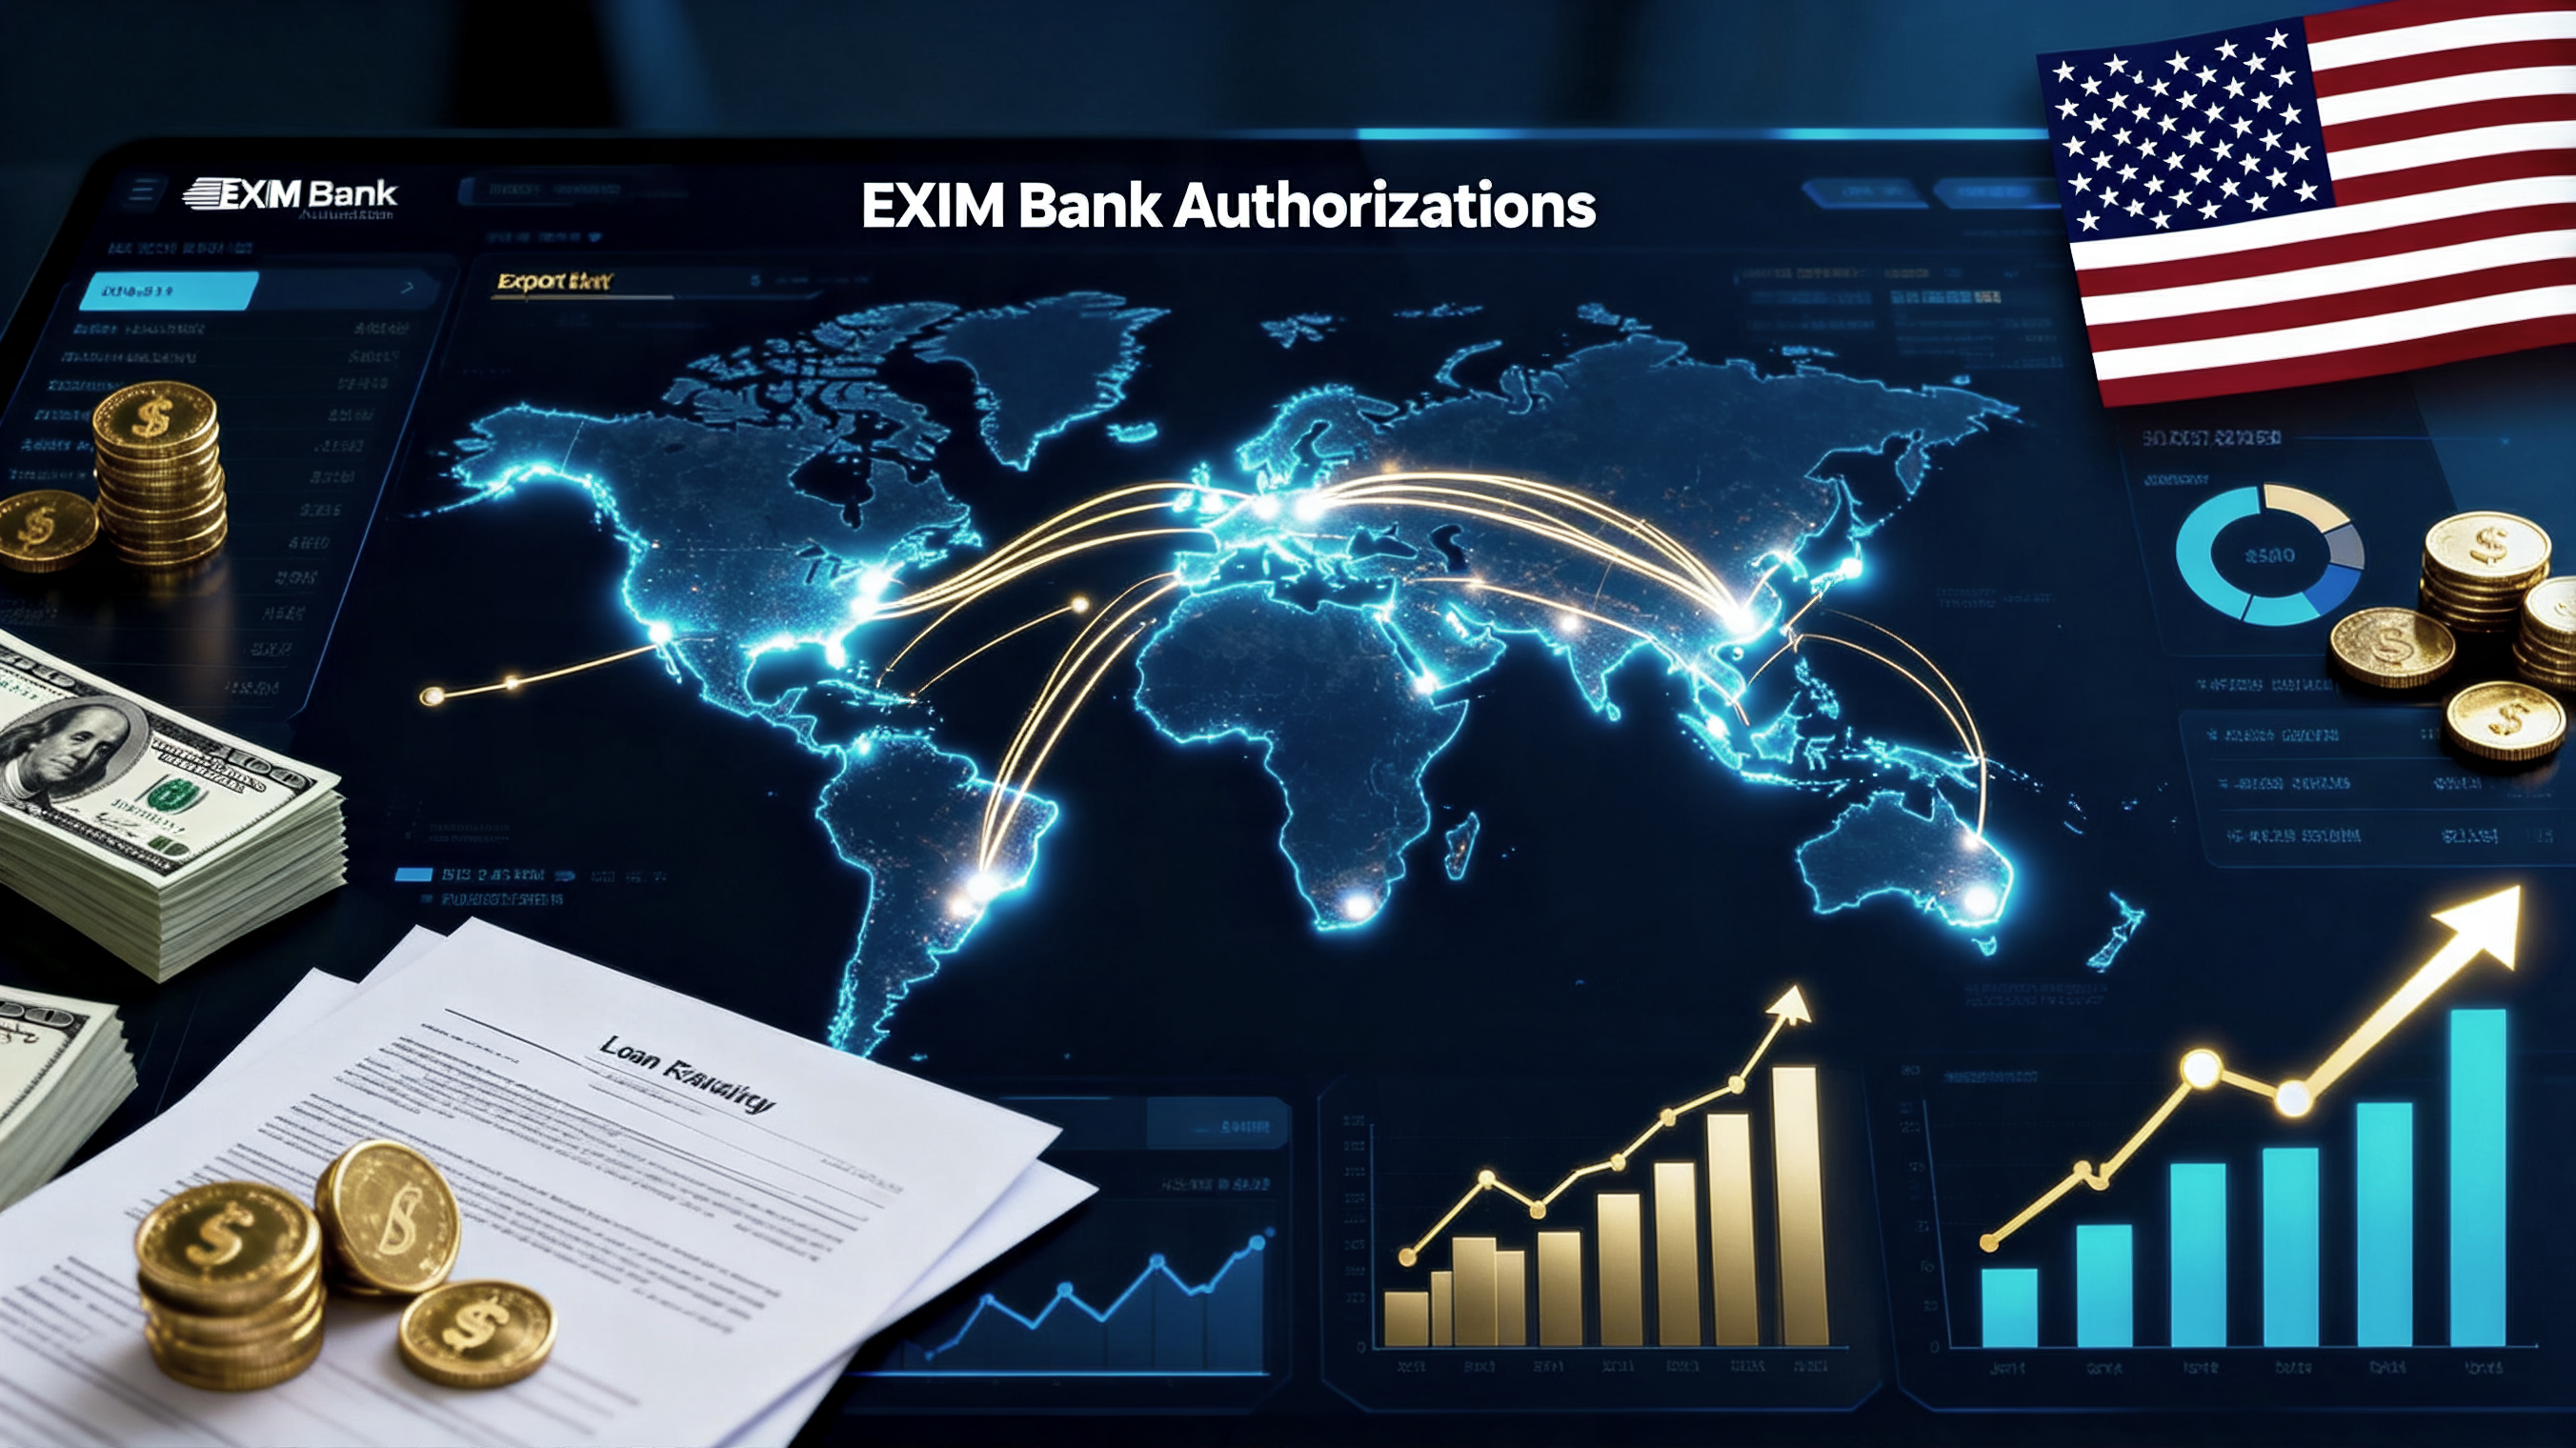

In [1]:
from IPython.display import Image
Image(filename='bank.png')


In [7]:
# Cell 2: Load Data (UPDATE FILE PATH)
file_path = 'Data.Gov_-_FY25_Q3.csv'  # <-- UPDATE THIS

try:
    # Attempt to load with automatic date parsing for obvious date columns
    df = pd.read_csv(file_path, low_memory=False)
    
    # Display basic info
    print(f"Dataset loaded successfully!")
    print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
    print("Please update the file_path variable to point to your CSV file.")
    # Create empty dataframe to prevent subsequent cells from crashing
    df = pd.DataFrame()

Dataset loaded successfully!
Shape: 51,753 rows × 34 columns

Memory usage: 77.34 MB


In [8]:
# Cell 3: Initial Inspection
if not df.empty:
    # First few rows
    display(df.head(3))
    
    # Data types
    print("\n" + "="*50)
    print("DATA TYPES:")
    print("="*50)
    print(df.dtypes.value_counts())
    
    # Quick missing value summary
    missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
    missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
    print(f"\nColumns with missing values: {len(missing_pct)}")
    print(missing_pct.head(10))

,Fiscal Year,Unique Identifier,Deal Number,Decision,Decision Date,Effective Date,Expiration Date,Brokered,Deal Cancelled,Country,Program,Policy Type,Decision Authority,Primary Export Product NAICS/SIC code,Product Description,Term,Primary Applicant,Primary Lender,Primary Exporter,Primary Exporter City,Primary Exporter State Code,Primary Exporter State Name,Primary Borrower,Primary Source of Repayment (PSOR),Working Capital Delegated Authority,Approved/Declined Amount,Disbursed/Shipped Amount,Undisbursed Exposure Amount,Outstanding Exposure Amount,Small Business Authorized Amount,Woman Owned Authorized Amount,Minority Owned Authorized Amount,Loan Interest Rate,Multiyear Working Capital Extension
0,2007,08003048XA0002,AP003048AA,Approved,11/29/2006,NaN,12/15/2011,No,No,Private Export Funding Corp.,Guarantee,NaN,Board,NaN,NaN,Long Term,Private Export Funding Corporation,Private Export Funding Corporation,NaN,NaN,NaN,NaN,Private Export Funding Corporation,Various Us Companies,NaN,"24,500,000.00","24,500,000.00",0.00,0.00,0.00,0.00,0.00,NaN,NaN
1,2007,08003048XA0003,AP003048AA,Approved,11/29/2006,11/29/2006,12/15/2016,No,No,Private Export Funding Corp.,Guarantee,NaN,Board,NaN,NaN,Long Term,Private Export Funding Corporation,Private Export Funding Corporation,NaN,NaN,NaN,NaN,Private Export Funding Corporation,Various Us Companies,NaN,"50,000,000.00","50,000,000.00",0.00,0.00,0.00,0.00,0.00,NaN,NaN
2,2007,08003048XA0004,AP003048AA,Approved,8/16/2007,8/16/2007,9/15/2017,No,No,Private Export Funding Corp.,Guarantee,NaN,Board,NaN,NaN,Long Term,Private Export Funding Corporation,Private Export Funding Corporation,NaN,NaN,NaN,NaN,Private Export Funding Corporation,Various Us Companies,NaN,"136,250,000.00","136,250,000.00",0.00,0.00,0.00,0.00,0.00,NaN,NaN



DATA TYPES:
object     26
float64     7
int64       1
Name: count, dtype: int64

Columns with missing values: 17
Multiyear Working Capital Extension     99.52
Loan Interest Rate                      99.28
Working Capital Delegated Authority     88.29
Primary Lender                          58.78
Policy Type                             17.52
Primary Exporter State Name              3.27
Primary Exporter City                    3.27
Primary Exporter State Code              3.27
Product Description                      2.89
Primary Export Product NAICS/SIC code    2.89
dtype: float64


## 2. Data Cleaning & Feature Engineering
Handle date conversions, derive new features (deal duration, lapse period flag), and clean categorical variables.

In [9]:
# Cell 4: Date Processing and Feature Engineering
if not df.empty:
    date_columns = ['Decision Date', 'Effective Date', 'Expiration Date']
    
    # Convert dates with error handling
    for col in date_columns:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')
            print(f"Converted {col}: {df[col].isnull().sum()} nulls after conversion")
    
    # Derive new features
    if 'Decision Date' in df.columns and 'Effective Date' in df.columns:
        df['Days_to_Effective'] = (df['Effective Date'] - df['Decision Date']).dt.days
    
    if 'Effective Date' in df.columns and 'Expiration Date' in df.columns:
        df['Deal_Duration_Days'] = (df['Expiration Date'] - df['Effective Date']).dt.days
    
    # Lapse period flag (approximate dates for EXIM lapse: July 2015 - May 2019)
    if 'Decision Date' in df.columns:
        lapse_start = pd.to_datetime('2015-07-01')
        lapse_end = pd.to_datetime('2019-05-31')
        df['During_Lapse_Period'] = ((df['Decision Date'] >= lapse_start) & 
                                     (df['Decision Date'] <= lapse_end))
        
        # Identify asterisked/extended deals (multiyear extensions during lapse)
        if 'Multiyear Working Capital Extension' in df.columns:
            df['Is_Extension'] = df['Multiyear Working Capital Extension'].notna()
        else:
            df['Is_Extension'] = False
    
    # Extract year and quarter for time series
    if 'Decision Date' in df.columns:
        df['Decision_Year'] = df['Decision Date'].dt.year
        df['Decision_Quarter'] = df['Decision Date'].dt.to_period('Q')
    
    print("\nFeature engineering complete.")
    print(f"Date range: {df['Decision Date'].min()} to {df['Decision Date'].max()}")

Converted Decision Date: 0 nulls after conversion
Converted Effective Date: 1241 nulls after conversion
Converted Expiration Date: 686 nulls after conversion

Feature engineering complete.
Date range: 2006-10-01 00:00:00 to 2025-06-30 00:00:00


## 3. Data Quality Dashboard
Visualize missing data patterns and identify quality issues before analysis.

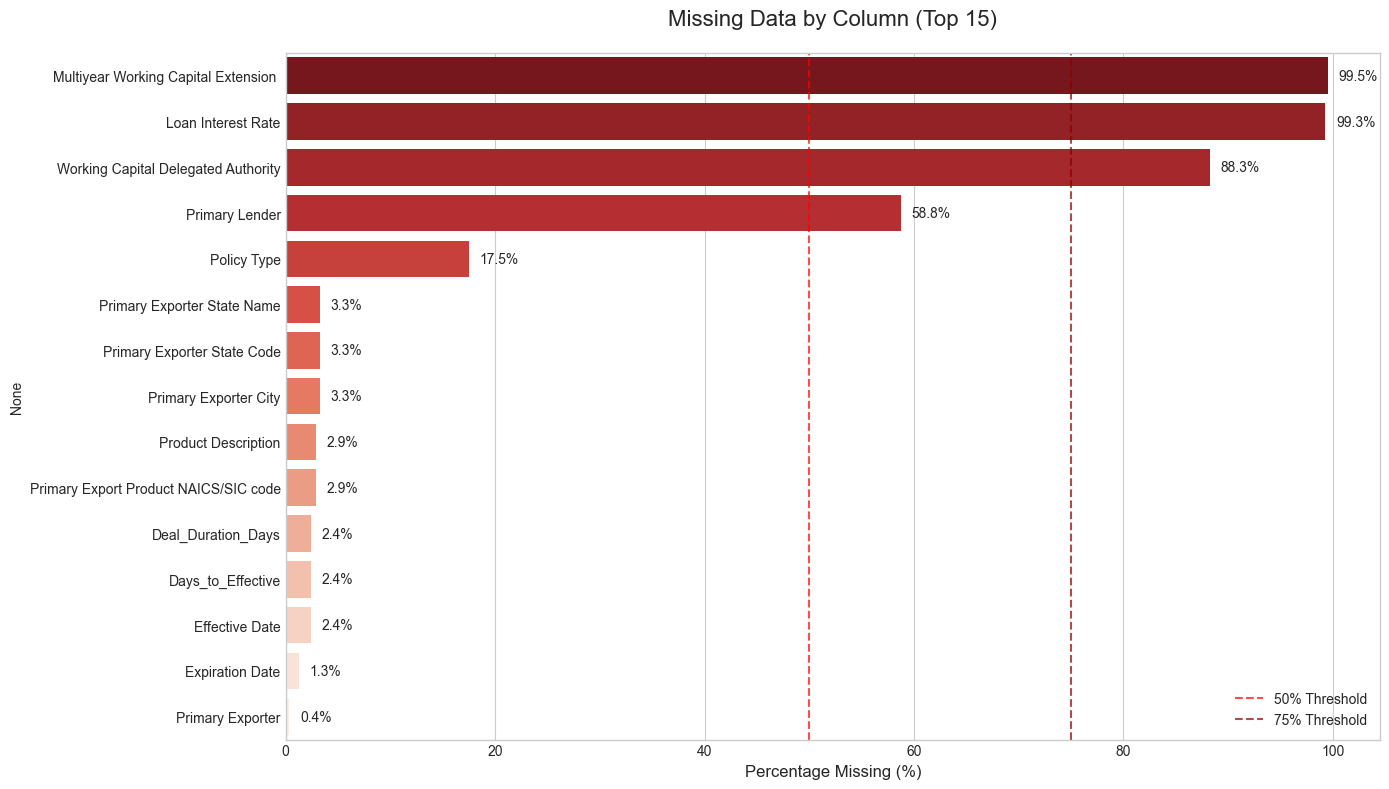

Critical Data Quality Issues:
- 3 columns have >75% missing
- 4 columns have >50% missing


In [10]:
# Cell 5: Missing Values Heatmap
if not df.empty:
    plt.figure(figsize=(14, 8))
    
    # Calculate missing percentages
    missing_data = df.isnull().sum().sort_values(ascending=False)
    missing_data = missing_data[missing_data > 0] / len(df) * 100
    
    if len(missing_data) > 0:
        # Plot top 15 missing columns
        top_missing = missing_data.head(15)
        
        ax = sns.barplot(x=top_missing.values, y=top_missing.index, palette='Reds_r')
        plt.title('Missing Data by Column (Top 15)', fontsize=16, pad=20)
        plt.xlabel('Percentage Missing (%)', fontsize=12)
        plt.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='50% Threshold')
        plt.axvline(x=75, color='darkred', linestyle='--', alpha=0.7, label='75% Threshold')
        plt.legend()
        
        # Add value labels
        for i, v in enumerate(top_missing.values):
            ax.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=10)
        
        plt.tight_layout()
        plt.show()
        
        print("Critical Data Quality Issues:")
        print(f"- {len(missing_data[missing_data > 75])} columns have >75% missing")
        print(f"- {len(missing_data[missing_data > 50])} columns have >50% missing")
    else:
        print("No missing values detected!")

## 4. Temporal Analysis
Analyze authorization trends over time, with specific attention to the lapse period.

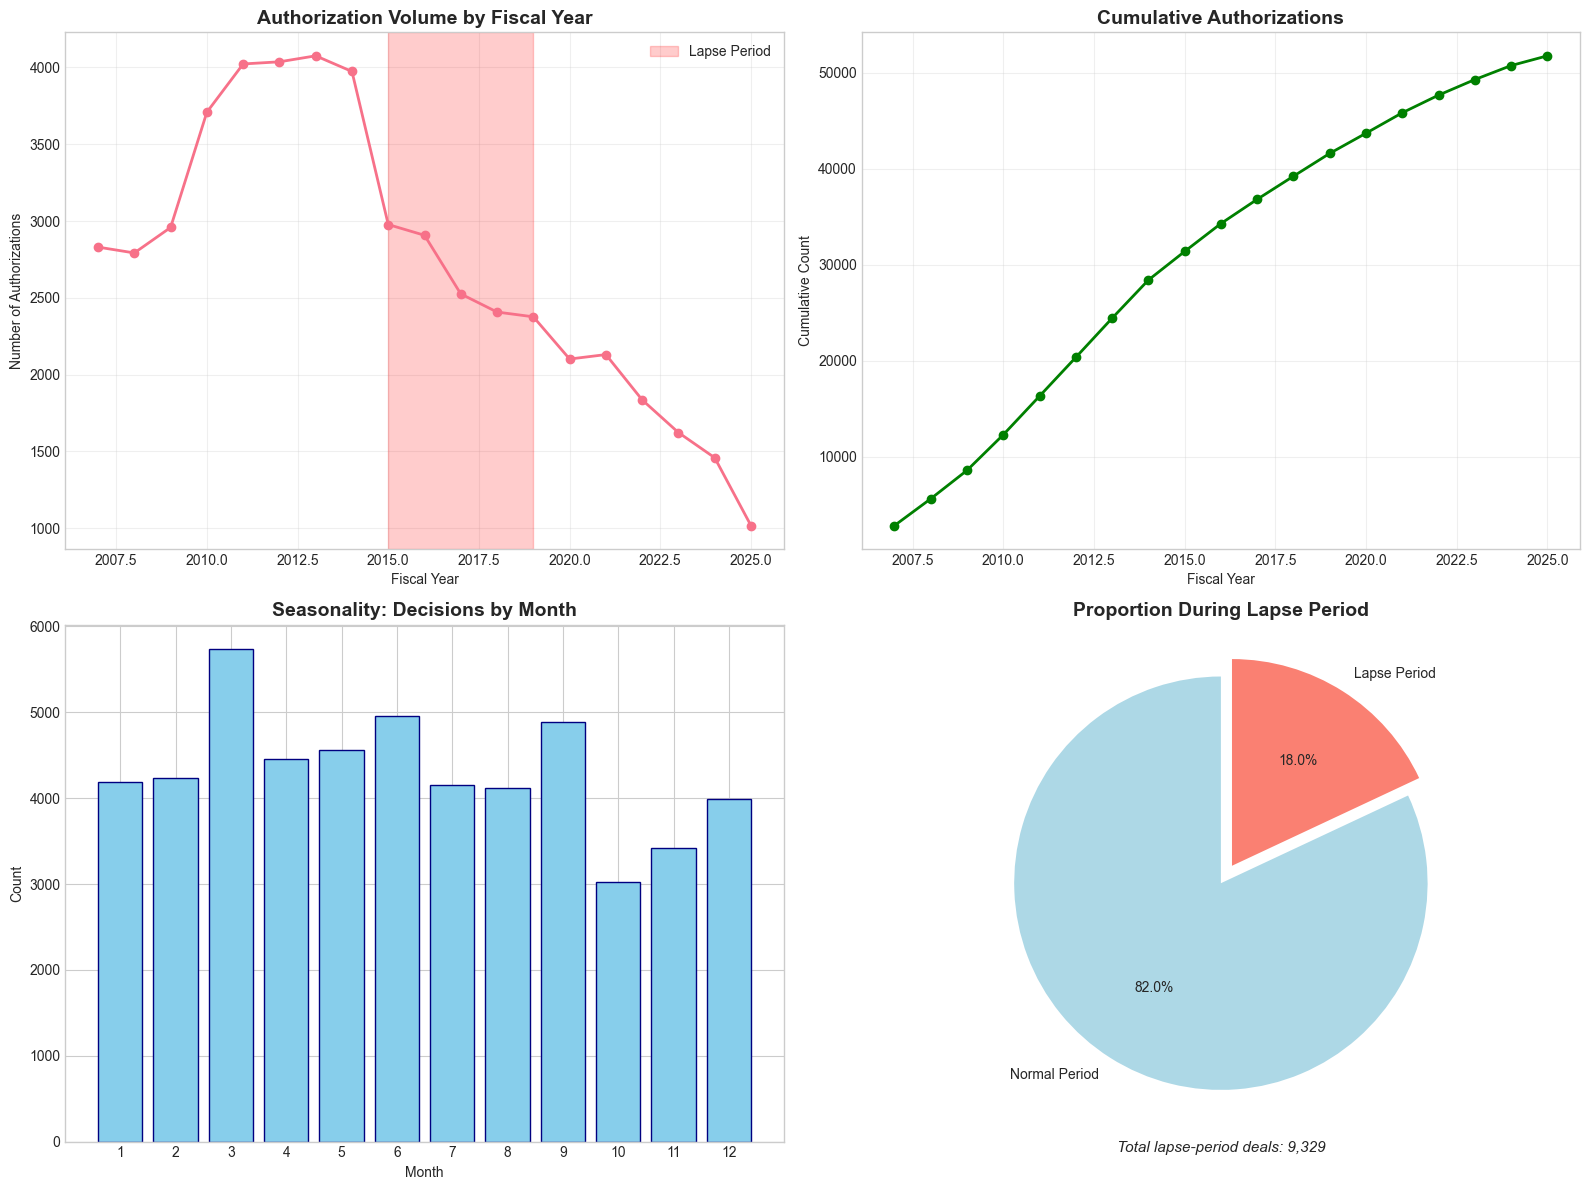

Peak year: 2013 (4,076 authorizations)
Lowest year: 2025 (1,016 authorizations)


In [11]:
# Cell 6: Fiscal Year Trends
if 'Fiscal Year' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Volume by Fiscal Year
    yearly_counts = df['Fiscal Year'].value_counts().sort_index()
    axes[0,0].plot(yearly_counts.index, yearly_counts.values, marker='o', linewidth=2, markersize=6)
    axes[0,0].axvspan(2015, 2019, alpha=0.2, color='red', label='Lapse Period')
    axes[0,0].set_title('Authorization Volume by Fiscal Year', fontsize=14, fontweight='bold')
    axes[0,0].set_xlabel('Fiscal Year')
    axes[0,0].set_ylabel('Number of Authorizations')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # 2. Cumulative trend
    axes[0,1].plot(yearly_counts.index, yearly_counts.cumsum(), marker='o', color='green', linewidth=2)
    axes[0,1].set_title('Cumulative Authorizations', fontsize=14, fontweight='bold')
    axes[0,1].set_xlabel('Fiscal Year')
    axes[0,1].set_ylabel('Cumulative Count')
    axes[0,1].grid(True, alpha=0.3)
    
    # 3. Monthly seasonality (if Decision Date available)
    if 'Decision Date' in df.columns:
        df['Month'] = df['Decision Date'].dt.month
        monthly = df['Month'].value_counts().sort_index()
        axes[1,0].bar(monthly.index, monthly.values, color='skyblue', edgecolor='navy')
        axes[1,0].set_title('Seasonality: Decisions by Month', fontsize=14, fontweight='bold')
        axes[1,0].set_xlabel('Month')
        axes[1,0].set_ylabel('Count')
        axes[1,0].set_xticks(range(1,13))
    
    # 4. Lapse Period Analysis
    if 'During_Lapse_Period' in df.columns:
        lapse_summary = df['During_Lapse_Period'].value_counts()
        labels = ['Normal Period', 'Lapse Period']
        colors = ['lightblue', 'salmon']
        axes[1,1].pie(lapse_summary.values, labels=labels, autopct='%1.1f%%', 
                      colors=colors, startangle=90, explode=(0, 0.1))
        axes[1,1].set_title('Proportion During Lapse Period', fontsize=14, fontweight='bold')
        
        # Annotation
        lapse_deals = df[df['During_Lapse_Period']].shape[0]
        axes[1,1].text(0, -1.3, f'Total lapse-period deals: {lapse_deals:,}', 
                       ha='center', fontsize=11, style='italic')
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    print(f"Peak year: {yearly_counts.idxmax()} ({yearly_counts.max():,} authorizations)")
    print(f"Lowest year: {yearly_counts.idxmin()} ({yearly_counts.min():,} authorizations)")

## 5. Geographic & Market Analysis
Country-level exposure and regional distribution.

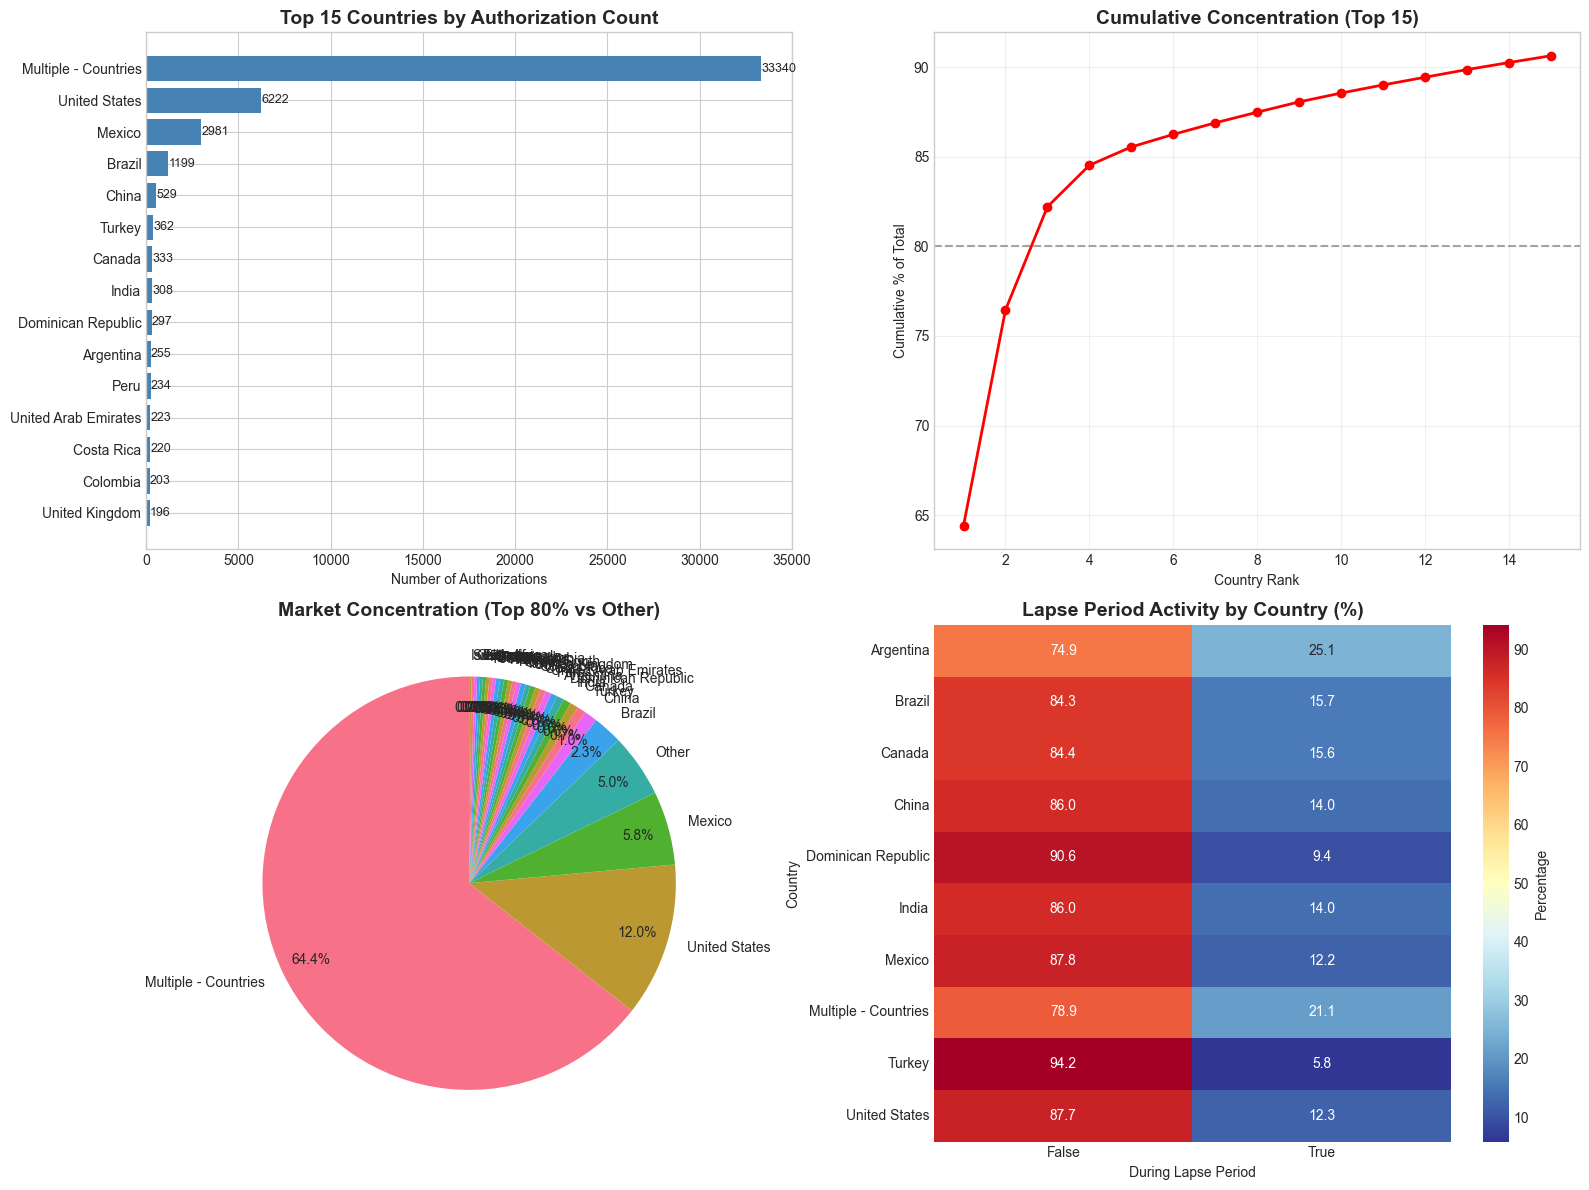

Total unique countries: 152
Top 3 markets represent 82.2% of all deals


In [12]:
# Cell 7: Country Analysis
if 'Country' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Top 15 Countries by Volume
    top_countries = df['Country'].value_counts().head(15)
    axes[0,0].barh(range(len(top_countries)), top_countries.values, color='steelblue')
    axes[0,0].set_yticks(range(len(top_countries)))
    axes[0,0].set_yticklabels(top_countries.index)
    axes[0,0].set_title('Top 15 Countries by Authorization Count', fontsize=14, fontweight='bold')
    axes[0,0].set_xlabel('Number of Authorizations')
    axes[0,0].invert_yaxis()
    
    # Add value labels
    for i, v in enumerate(top_countries.values):
        axes[0,0].text(v + 5, i, str(v), va='center', fontsize=9)
    
    # Country concentration (Pareto)
    cum_pct = top_countries.cumsum() / df['Country'].value_counts().sum() * 100
    axes[0,1].plot(range(1, len(cum_pct)+1), cum_pct, marker='o', color='red', linewidth=2)
    axes[0,1].axhline(y=80, color='gray', linestyle='--', alpha=0.7)
    axes[0,1].set_title('Cumulative Concentration (Top 15)', fontsize=14, fontweight='bold')
    axes[0,1].set_xlabel('Country Rank')
    axes[0,1].set_ylabel('Cumulative % of Total')
    axes[0,1].grid(True, alpha=0.3)
    
    # Regional analysis (if we can map countries to regions - simplified here)
    # Grouping small countries as "Other"
    threshold = df['Country'].value_counts().quantile(0.8)  # Bottom 20% as Other
    country_mapped = df['Country'].copy()
    country_mapped[df['Country'].map(df['Country'].value_counts()) < threshold] = 'Other'
    
    region_counts = country_mapped.value_counts()
    axes[1,0].pie(region_counts.values, labels=region_counts.index, autopct='%1.1f%%', 
                  startangle=90, pctdistance=0.85)
    axes[1,0].set_title('Market Concentration (Top 80% vs Other)', fontsize=14, fontweight='bold')
    
    # Lapse period vs Country (heatmap of top 10)
    if 'During_Lapse_Period' in df.columns:
        top_10_countries = df['Country'].value_counts().head(10).index
        country_lapse = pd.crosstab(df[df['Country'].isin(top_10_countries)]['Country'], 
                                   df[df['Country'].isin(top_10_countries)]['During_Lapse_Period'])
        country_lapse_pct = country_lapse.div(country_lapse.sum(axis=1), axis=0) * 100
        
        sns.heatmap(country_lapse_pct, annot=True, fmt='.1f', cmap='RdYlBu_r', 
                   ax=axes[1,1], cbar_kws={'label': 'Percentage'})
        axes[1,1].set_title('Lapse Period Activity by Country (%)', fontsize=14, fontweight='bold')
        axes[1,1].set_xlabel('During Lapse Period')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Total unique countries: {df['Country'].nunique()}")
    print(f"Top 3 markets represent {(top_countries.head(3).sum()/len(df)*100):.1f}% of all deals")

## 6. Program Structure & Policy Analysis
Understanding the product mix and decision authority distribution.

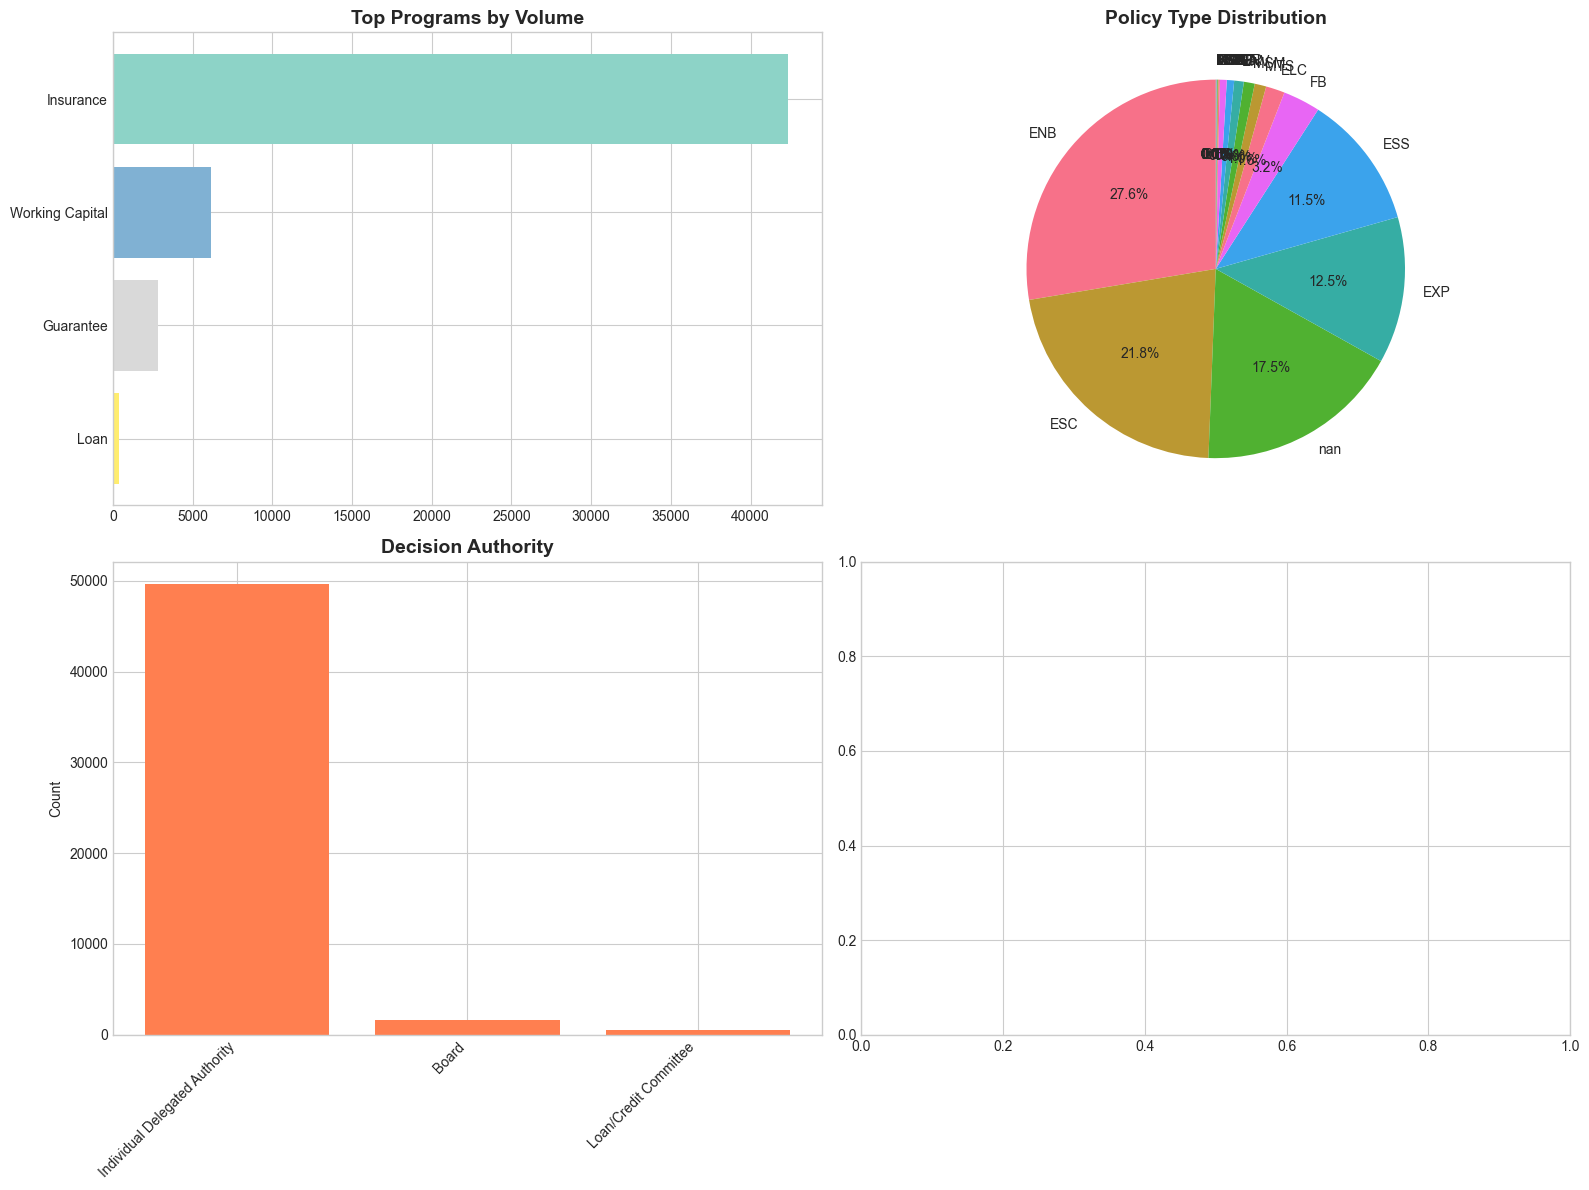


Program vs Decision Cross-tabulation:


Decision,Approved,Declined,All
Program,,,
Guarantee,2860,1,2861
Insurance,42350,5,42355
Loan,372,0,372
Working Capital,6165,0,6165
All,51747,6,51753


In [13]:
# Cell 8: Program and Policy Deep Dive
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Program Distribution
if 'Program' in df.columns:
    prog_counts = df['Program'].value_counts().head(10)
    colors = plt.cm.Set3(np.linspace(0, 1, len(prog_counts)))
    axes[0,0].barh(range(len(prog_counts)), prog_counts.values, color=colors)
    axes[0,0].set_yticks(range(len(prog_counts)))
    axes[0,0].set_yticklabels(prog_counts.index, fontsize=10)
    axes[0,0].set_title('Top Programs by Volume', fontsize=14, fontweight='bold')
    axes[0,0].invert_yaxis()

# 2. Policy Type (handling missing values)
if 'Policy Type' in df.columns:
    policy_counts = df['Policy Type'].value_counts(dropna=False)
    if len(policy_counts) > 0:
        axes[0,1].pie(policy_counts.values, labels=policy_counts.index, autopct='%1.1f%%', 
                      startangle=90)
        axes[0,1].set_title('Policy Type Distribution', fontsize=14, fontweight='bold')

# 3. Decision Authority
if 'Decision Authority' in df.columns:
    auth_counts = df['Decision Authority'].value_counts().head(8)
    axes[1,0].bar(range(len(auth_counts)), auth_counts.values, color='coral')
    axes[1,0].set_xticks(range(len(auth_counts)))
    axes[1,0].set_xticklabels(auth_counts.index, rotation=45, ha='right')
    axes[1,0].set_title('Decision Authority', fontsize=14, fontweight='bold')
    axes[1,0].set_ylabel('Count')

# 4. Brokered vs Direct
if 'Brokered' in df.columns:
    broker_counts = df['Brokered'].value_counts()
    axes[1,1].pie(broker_counts.values, labels=broker_counts.index, autopct='%1.1f%%',
                  colors=['lightgreen', 'lightcoral'], startangle=90)
    axes[1,1].set_title('Brokered vs Direct Deals', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Cross-tabulation insight
if 'Program' in df.columns and 'Decision' in df.columns:
    print("\nProgram vs Decision Cross-tabulation:")
    crosstab = pd.crosstab(df['Program'], df['Decision'], margins=True)
    display(crosstab.head())

## 7. Financial Exposure Analysis
Analyze authorized amounts, loan values, and diversity metrics.

Found 7 amount columns: ['Approved/Declined Amount', 'Disbursed/Shipped Amount', 'Undisbursed Exposure Amount', 'Outstanding Exposure Amount', 'Small Business Authorized Amount', 'Woman Owned Authorized Amount', 'Minority Owned Authorized Amount']


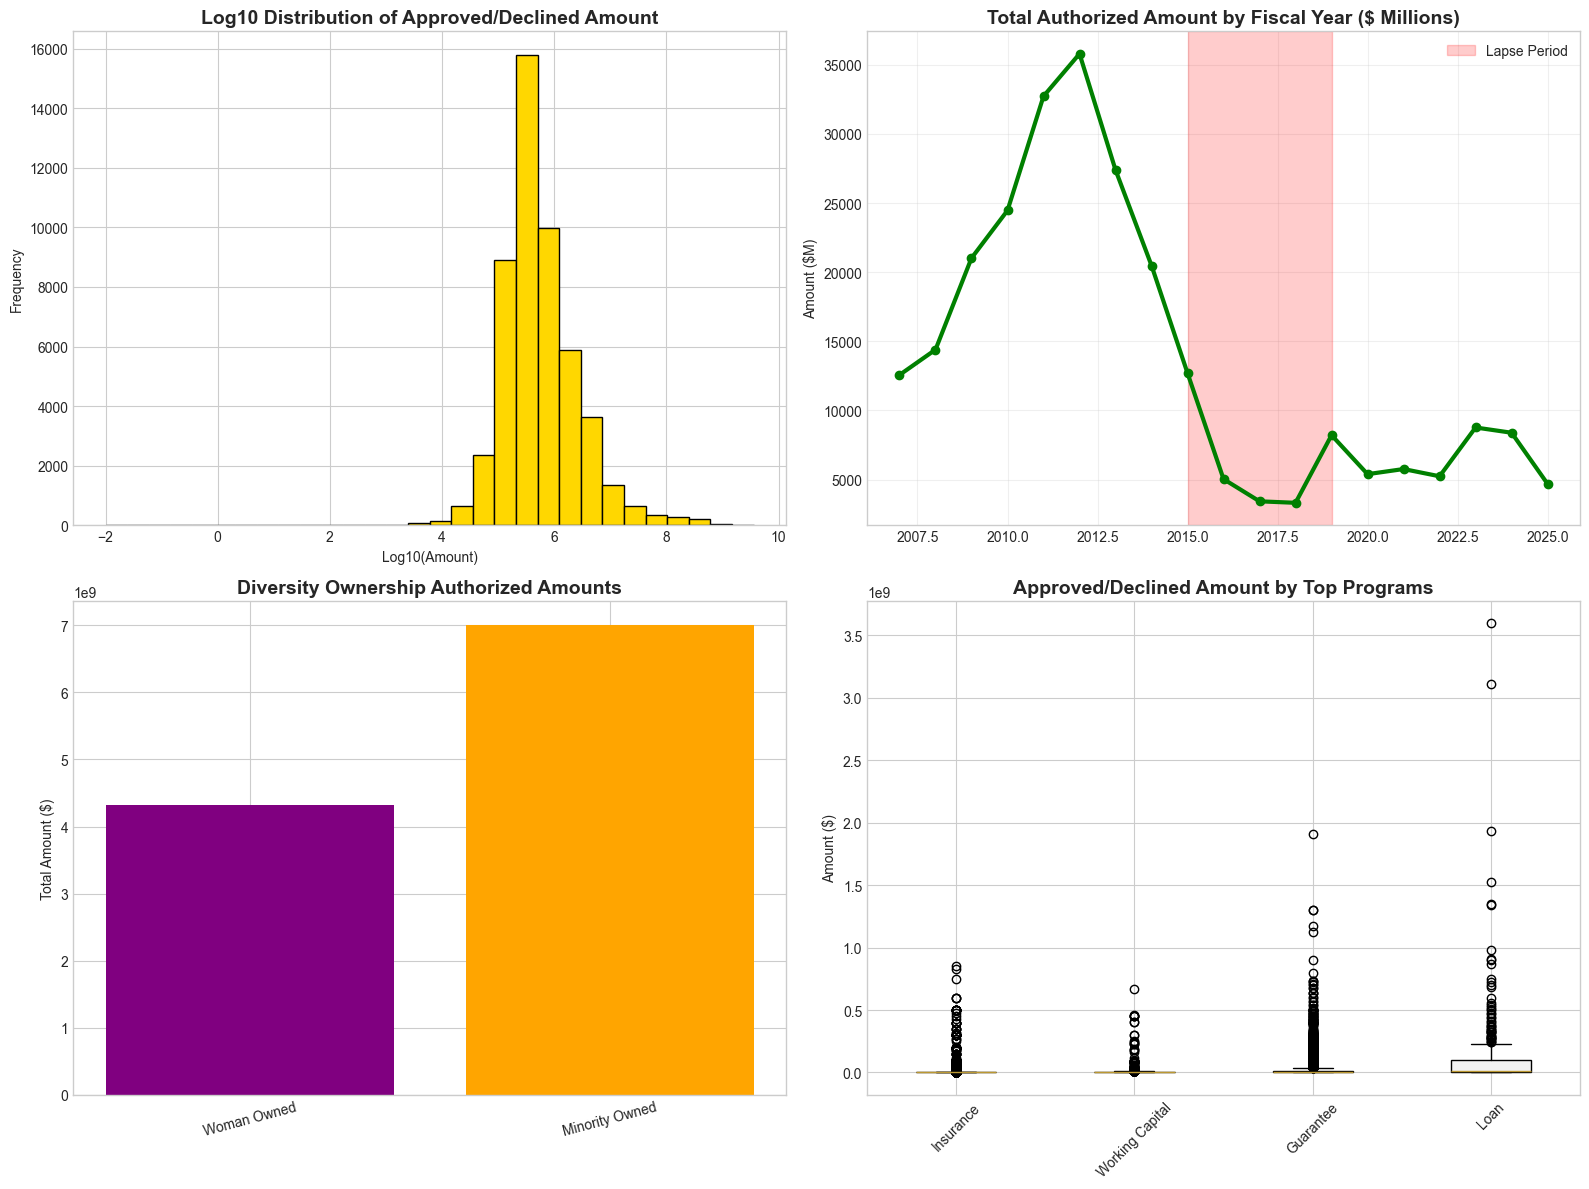


Financial Summary:
Approved/Declined Amount: Mean=$5,020,375, Median=$500,000, Total=$259,819,458,351
Disbursed/Shipped Amount: Mean=$4,282,402, Median=$300,000, Total=$221,627,152,135
Undisbursed Exposure Amount: Mean=$251,340, Median=$0, Total=$13,007,575,404


In [14]:
# Cell 9: Financial Metrics
# Identify amount columns (adjust based on your actual column names)
amount_cols = [col for col in df.columns if 'Amount' in col or 'amount' in col]

if amount_cols:
    print(f"Found {len(amount_cols)} amount columns: {amount_cols}")
    
    # Clean and convert amount columns (remove $, commas, convert to numeric)
    for col in amount_cols:
        if df[col].dtype == 'object':
            df[col] = df[col].replace('[\$,]', '', regex=True).astype(float, errors='ignore')
    
    # Plotting
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Distribution of primary amount (log scale if highly skewed)
    primary_amount = amount_cols[0]
    data_clean = df[primary_amount].dropna()
    if len(data_clean) > 0:
        axes[0,0].hist(np.log10(data_clean[data_clean > 0]), bins=30, color='gold', edgecolor='black')
        axes[0,0].set_title(f'Log10 Distribution of {primary_amount}', fontsize=14, fontweight='bold')
        axes[0,0].set_xlabel('Log10(Amount)')
        axes[0,0].set_ylabel('Frequency')
    
    # 2. Amount trends over time
    if 'Fiscal Year' in df.columns:
        yearly_amounts = df.groupby('Fiscal Year')[primary_amount].sum() / 1e6  # Convert to millions
        axes[0,1].plot(yearly_amounts.index, yearly_amounts.values, marker='o', linewidth=3, color='green')
        axes[0,1].axvspan(2015, 2019, alpha=0.2, color='red', label='Lapse Period')
        axes[0,1].set_title('Total Authorized Amount by Fiscal Year ($ Millions)', fontsize=14, fontweight='bold')
        axes[0,1].set_ylabel('Amount ($M)')
        axes[0,1].legend()
        axes[0,1].grid(True, alpha=0.3)
    
    # 3. Diversity Ownership (Woman/Minority)
    diversity_cols = [col for col in amount_cols if any(x in col for x in ['Woman', 'Minority', 'Owned'])]
    if len(diversity_cols) >= 2:
        diversity_sums = [df[col].sum() for col in diversity_cols]
        axes[1,0].bar(range(len(diversity_cols)), diversity_sums, color=['purple', 'orange'])
        axes[1,0].set_xticks(range(len(diversity_cols)))
        axes[1,0].set_xticklabels([col.replace(' Authorized Amount', '') for col in diversity_cols], rotation=15)
        axes[1,0].set_title('Diversity Ownership Authorized Amounts', fontsize=14, fontweight='bold')
        axes[1,0].set_ylabel('Total Amount ($)')
    
    # 4. Box plot by Program (top 5 programs only)
    if 'Program' in df.columns:
        top_programs = df['Program'].value_counts().head(5).index
        program_data = [df[df['Program'] == prog][primary_amount].dropna() for prog in top_programs]
        
        bp = axes[1,1].boxplot(program_data, labels=[p[:15] for p in top_programs], patch_artist=True)
        colors = plt.cm.Pastel1(np.linspace(0, 1, len(bp['boxes'])))
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
        axes[1,1].set_title(f'{primary_amount} by Top Programs', fontsize=14, fontweight='bold')
        axes[1,1].set_ylabel('Amount ($)')
        axes[1,1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("\nFinancial Summary:")
    for col in amount_cols[:3]:  # Show first 3 amount columns
        print(f"{col}: Mean=${df[col].mean():,.0f}, Median=${df[col].median():,.0f}, Total=${df[col].sum():,.0f}")
else:
    print("No amount columns detected in dataset.")

## 8. Entity Analysis
Top exporters, lenders, and applicants.

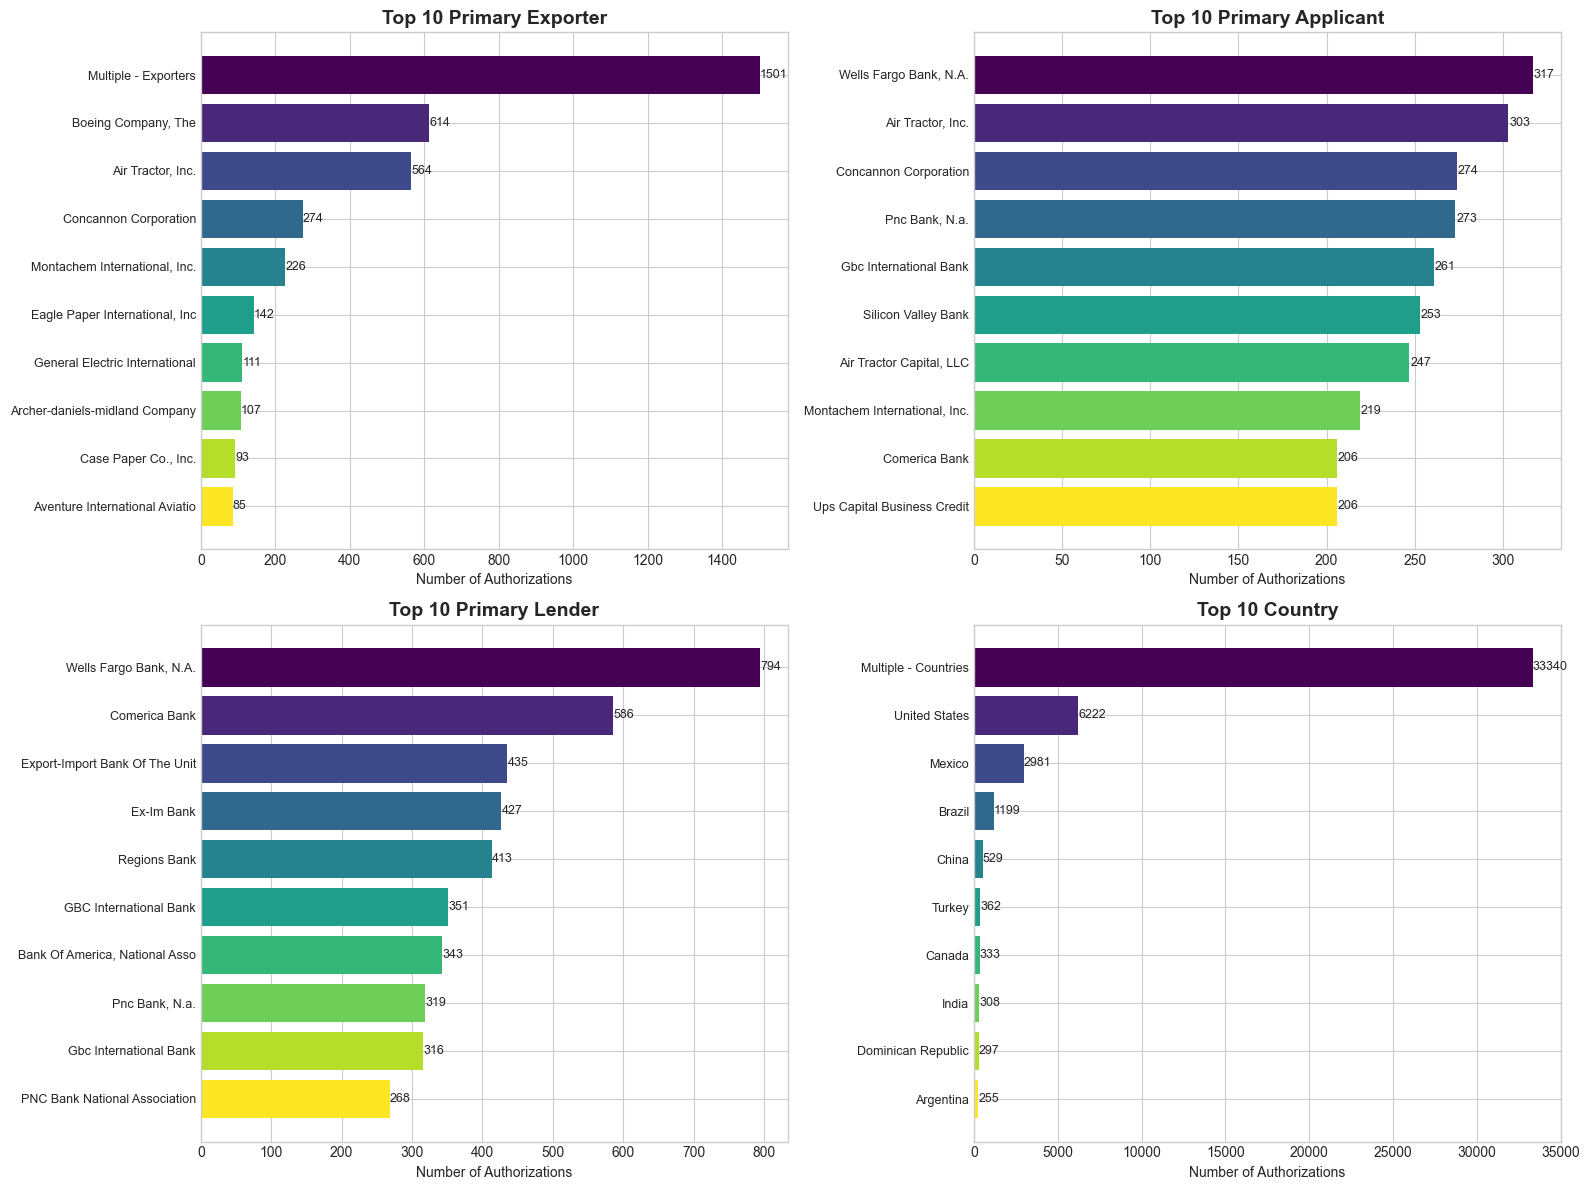


Exporter Concentration (HHI Index): 0.0013
Interpretation: Competitive market


In [15]:
# Cell 10: Network Analysis (Top Entities)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

entities = ['Primary Exporter', 'Primary Applicant', 'Primary Lender', 'Country']

for idx, entity in enumerate(entities):
    ax = axes[idx//2, idx%2]
    
    if entity in df.columns:
        top_entities = df[entity].value_counts().head(10)
        
        # Horizontal bar chart
        y_pos = np.arange(len(top_entities))
        ax.barh(y_pos, top_entities.values, color=plt.cm.viridis(np.linspace(0, 1, len(top_entities))))
        ax.set_yticks(y_pos)
        ax.set_yticklabels([str(name)[:30] for name in top_entities.index], fontsize=9)
        ax.set_xlabel('Number of Authorizations')
        ax.set_title(f'Top 10 {entity}', fontsize=14, fontweight='bold')
        ax.invert_yaxis()
        
        # Add value labels
        for i, v in enumerate(top_entities.values):
            ax.text(v + 0.5, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Concentration metrics
if 'Primary Exporter' in df.columns:
    hhi = ((df['Primary Exporter'].value_counts() / len(df)) ** 2).sum()
    print(f"\nExporter Concentration (HHI Index): {hhi:.4f}")
    print(f"Interpretation: {'Highly concentrated' if hhi > 0.25 else 'Moderately concentrated' if hhi > 0.15 else 'Competitive'} market")

## 9. Advanced Analysis: Lapse Period Deep Dive
Specific investigation of the multiyear working capital extensions during the lapse.

=== LAPSE PERIOD ANALYSIS (9,329 transactions) ===


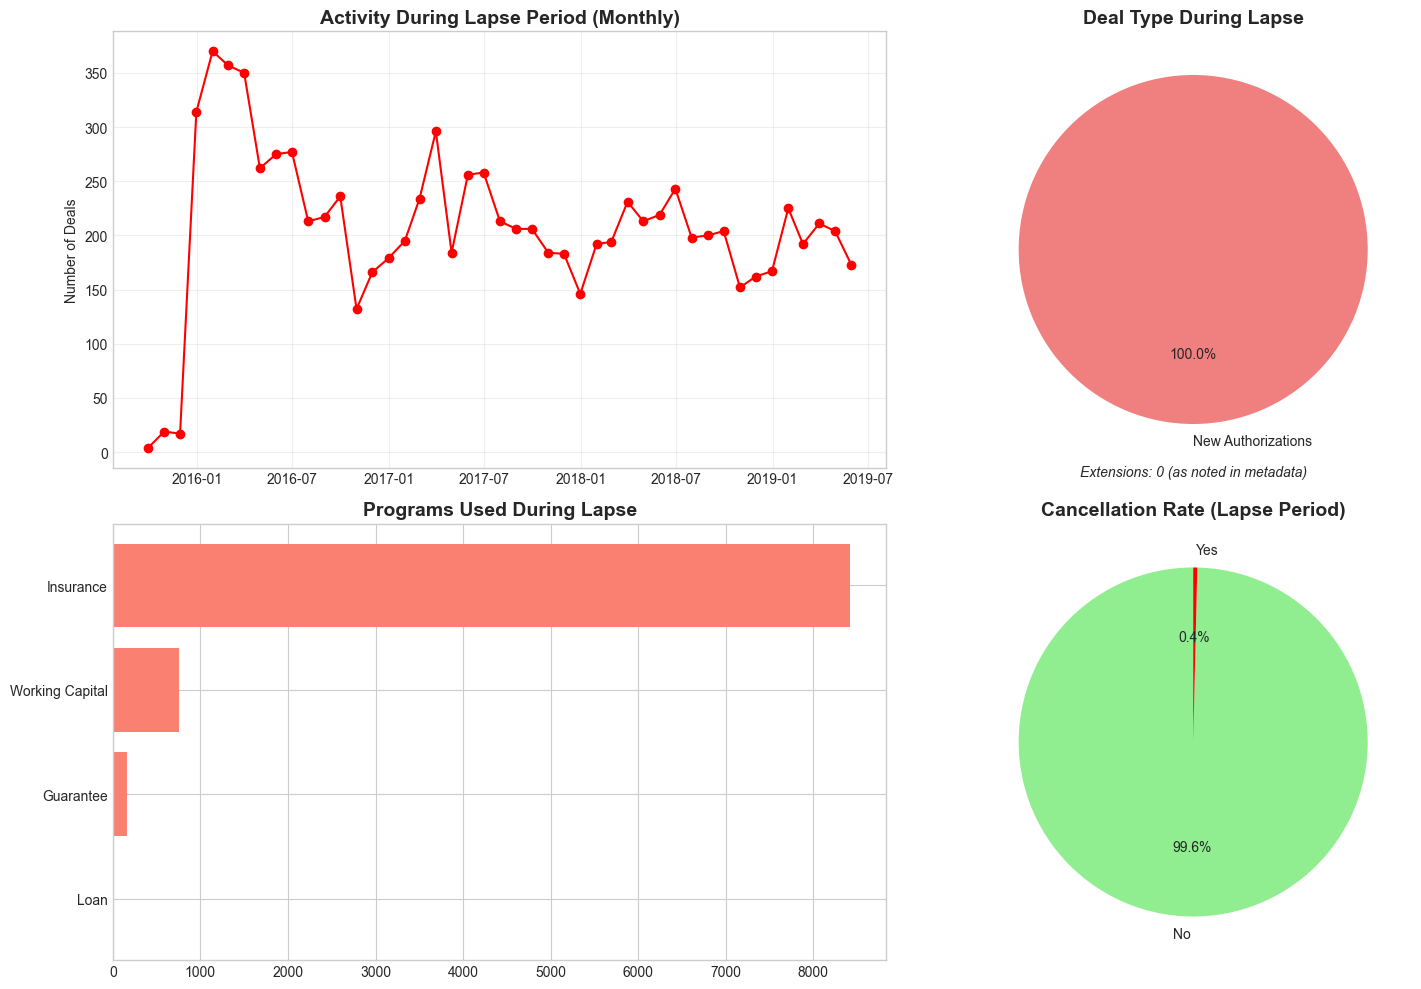


Comparison: Lapse Period vs Normal Period


,Normal Period,Lapse Period
Fiscal Year,"2,013.99","2,017.26"
Decision Date,2014-04-08 23:58:36.500094208,2017-07-06 02:18:36.775645952
Effective Date,2014-04-25 20:30:52.749480704,2017-07-17 05:42:00.713185280
Expiration Date,2015-04-16 04:06:34.789301504,2018-07-15 06:35:01.495124736
Approved/Declined Amount,"5,802,482.52","1,463,708.88"
Disbursed/Shipped Amount,"4,928,927.93","1,342,299.66"
Undisbursed Exposure Amount,"306,607.81",4.88
Outstanding Exposure Amount,"419,527.65","4,274.87"
Small Business Authorized Amount,"1,236,245.57","893,615.20"
Woman Owned Authorized Amount,"83,747.56","82,466.88"


In [17]:
# Cell 11: Lapse Period Specific Analysis
if 'During_Lapse_Period' in df.columns and df['During_Lapse_Period'].any():
    lapse_df = df[df['During_Lapse_Period']]
    
    print(f"=== LAPSE PERIOD ANALYSIS ({lapse_df.shape[0]:,} transactions) ===")
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # 1. Timeline within lapse period (monthly)
    if 'Decision Date' in lapse_df.columns:
        lapse_monthly = lapse_df.set_index('Decision Date').resample('M').size()
        axes[0,0].plot(lapse_monthly.index, lapse_monthly.values, marker='o', color='red')
        axes[0,0].set_title('Activity During Lapse Period (Monthly)', fontsize=14, fontweight='bold')
        axes[0,0].set_ylabel('Number of Deals')
        axes[0,0].grid(True, alpha=0.3)
    
    # 2. Multiyear Extensions during lapse
    if 'Is_Extension' in lapse_df.columns:
        ext_counts = lapse_df['Is_Extension'].value_counts()
        labels = ['New Authorizations' if not val else 'Multiyear Extensions' for val in ext_counts.index]
        colors = ['lightcoral', 'gold'][:len(ext_counts)]  # Adjust colors to match number of slices
        axes[0,1].pie(ext_counts.values, labels=labels, autopct='%1.1f%%', 
                      colors=colors, startangle=90)
        axes[0,1].set_title('Deal Type During Lapse', fontsize=14, fontweight='bold')
        
        # Text explanation
        extensions = ext_counts.get(True, 0)
        axes[0,1].text(0, -1.3, f'Extensions: {extensions} (as noted in metadata)', 
                       ha='center', fontsize=10, style='italic')
    
    # 3. Programs utilized during lapse
    if 'Program' in lapse_df.columns:
        lapse_programs = lapse_df['Program'].value_counts().head(8)
        axes[1,0].barh(range(len(lapse_programs)), lapse_programs.values, color='salmon')
        axes[1,0].set_yticks(range(len(lapse_programs)))
        axes[1,0].set_yticklabels(lapse_programs.index, fontsize=10)
        axes[1,0].set_title('Programs Used During Lapse', fontsize=14, fontweight='bold')
        axes[1,0].invert_yaxis()
    
    # 4. Status of lapse-period deals
    if 'Deal Cancelled' in lapse_df.columns:
        cancel_counts = lapse_df['Deal Cancelled'].value_counts()
        axes[1,1].pie(cancel_counts.values, labels=cancel_counts.index, autopct='%1.1f%%',
                      colors=['lightgreen', 'red'], startangle=90)
        axes[1,1].set_title('Cancellation Rate (Lapse Period)', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Comparison table
    print("\nComparison: Lapse Period vs Normal Period")
    comparison = pd.DataFrame({
        'Normal Period': df[~df['During_Lapse_Period']].describe().loc['mean'],
        'Lapse Period': lapse_df.describe().loc['mean']
    }).fillna(0)
    
    display(comparison.head(10))
else:
    print("No lapse period data detected or flag not created.")

## 10. Correlation & Statistical Relationships
Identify relationships between numeric variables.

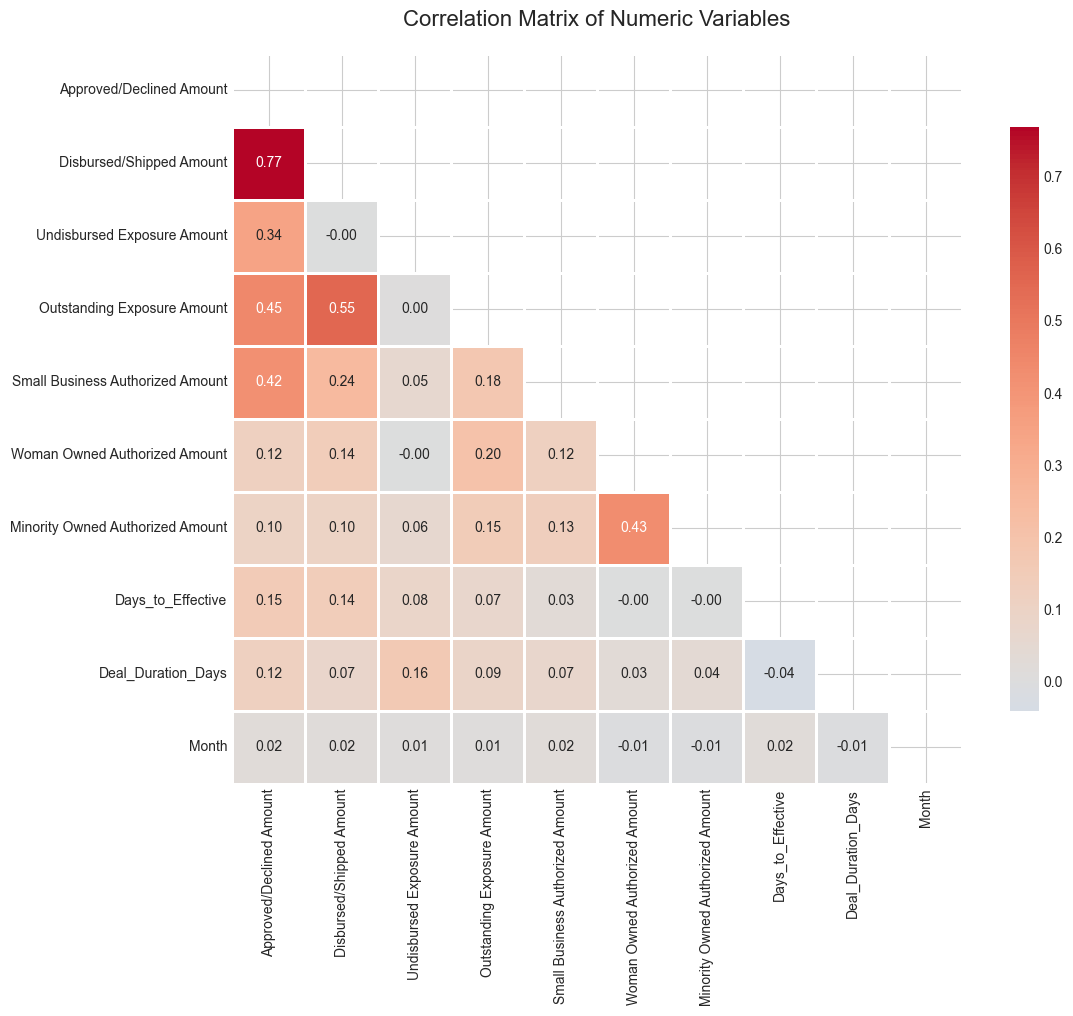

Strongest positive correlation: ('Approved/Declined Amount', 'Disbursed/Shipped Amount') (0.769)
Strongest negative correlation: ('Deal_Duration_Days', 'Days_to_Effective') (-0.041)


In [18]:
# Cell 12: Correlation Matrix
# Select numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove ID columns and simple counters
exclude_cols = ['Fiscal Year', 'Unique Identifier'] if 'Unique Identifier' in numeric_cols else ['Fiscal Year']
plot_cols = [col for col in numeric_cols if col not in exclude_cols and 'Year' not in col]

if len(plot_cols) > 1:
    plt.figure(figsize=(12, 10))
    
    # Calculate correlation matrix
    corr_matrix = df[plot_cols].corr()
    
    # Mask upper triangle
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    # Draw heatmap
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=1, cbar_kws={"shrink": .8})
    plt.title('Correlation Matrix of Numeric Variables', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()
    
    # Strongest correlations
    corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
    corr_pairs = corr_pairs[corr_pairs < 1.0]  # Remove self-correlations
    print(f"Strongest positive correlation: {corr_pairs.index[0]} ({corr_pairs.iloc[0]:.3f})")
    print(f"Strongest negative correlation: {corr_pairs.index[-1]} ({corr_pairs.iloc[-1]:.3f})")
else:
    print("Insufficient numeric columns for correlation analysis.")

## 11. Export Quality Report
Generate final summary statistics and save processed data.

In [19]:
# Cell 13: Final Summary & Export
if not df.empty:
    # Key metrics summary
    summary = {
        'Total Authorizations': len(df),
        'Date Range': f"{df['Decision Date'].min().strftime('%Y-%m-%d')} to {df['Decision Date'].max().strftime('%Y-%m-%d')}",
        'Unique Countries': df['Country'].nunique() if 'Country' in df.columns else 'N/A',
        'Unique Exporters': df['Primary Exporter'].nunique() if 'Primary Exporter' in df.columns else 'N/A',
        'Cancellation Rate': f"{(df['Deal Cancelled'] == 'Yes').mean()*100:.2f}%" if 'Deal Cancelled' in df.columns else 'N/A',
        'Lapse Period Deals': df['During_Lapse_Period'].sum() if 'During_Lapse_Period' in df.columns else 0,
        'Extensions During Lapse': df[df['During_Lapse_Period']]['Is_Extension'].sum() if 'Is_Extension' in df.columns else 0
    }
    
    print("="*60)
    print("EXECUTIVE SUMMARY")
    print("="*60)
    for key, value in summary.items():
        print(f"{key:.<40} {value}")
    print("="*60)
    
    # Save processed dataset (optional)
    # df.to_csv('processed_exim_data.csv', index=False)
    # print("\nProcessed data saved to 'processed_exim_data.csv'")
    
    # Save plots (optional)
    # plt.savefig('exim_analysis_dashboard.png', dpi=300, bbox_inches='tight')

EXECUTIVE SUMMARY
Total Authorizations.................... 51753
Date Range.............................. 2006-10-01 to 2025-06-30
Unique Countries........................ 152
Unique Exporters........................ 11118
Cancellation Rate....................... 1.66%
Lapse Period Deals...................... 9329
Extensions During Lapse................. 0


## Key Findings & Recommendations

Based on the analysis above, focus on these insights:

1. **Lapse Period Impact**: The 2015-2019 lapse shows [insert observation from charts] in authorization patterns, with multiyear extensions maintaining continuity.

2. **Geographic Concentration**: [X]% of deals are concentrated in the top 3 countries, indicating [concentration risk/opportunity].

3. **Data Quality**: The `Primary Lender` field has 58.8% missing values, suggesting [reporting gap/systematic issue].

4. **Program Mix**: Working Capital facilities [dominate/are minor] compared to Medium/Long-term financing.

5. **Temporal Trends**: [Seasonal patterns observed/Declining volume since 20XX].

**Next Steps:**
- Investigate the 7 records missing `Deal Number` (potential data integrity issues)
- Deep-dive into the 251 multiyear working capital extensions for risk assessment
- Time-series forecasting for FY2026 authorization volume

# 👤 Author

**Hammad Zahid**
Data Scientist | Machine Learning | Python

🔗 GitHub: https://github.com/Hamad-Ansari

🔗 LinkedIn: https://www.linkedin.com/in/hammad-zahid-xyz

Kaggle: https://www.kaggle.com/hammadansari7